# Climate Change Data Analysis

Author: Tom Rowan, st20285213

## Introduction

Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

## Import Libraries

In [1]:
import os
import re
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering
import seaborn
%matplotlib inline

In [2]:
# Import my utility library file
import utils
from utils import graph_colours as graph_colours

## Task 1 - Import and Preprocess Data Sets

Task 1:
- i.	Download the dataset from the above link. 
- ii.	Do the necessary preprocessing for example i.e., check for any null value or outlier. If found replace that with mean value and delete repeating factors as necessary.


Reference: https://databank.worldbank.org/reports.aspx?source=2&Topic=19#advancedDownloadOptions

Accessed: 10/05/2024

Reference: https://ourworldindata.org/world-region-map-definitions

Accessed:  15/05/2024



## Countries and Region Dataset

The World Bank provides a simple dataset which classifies each country by region. This data will be used to enrich analysis of the main datasets.

To explore the relative size of the regions, I have performed a count and drawn a graph.

https://unstats.un.org/unsd/methodology/m49/overview/

In [3]:
# Load Data Set
countries_df = pd.read_csv('../datasets/countries/unsd-countrycodes.csv', delimiter=";")

# Rename and Drop Columns
countries_df.rename(columns={'Country or Area': 'Country', 'Region Name': 'Region', 'ISO-alpha3 Code': 'ISOcode'}, inplace=True)

# Produce Lists
countries = countries_df['Country'].unique()
regions = countries_df['Region'].unique()
country_codes = countries_df['ISOcode'].unique()

# countries.sort()
# regions.sort()
# country_codes.sort() --> TypeError: '<' not supported between instances of 'str' and 'float' ???

print (f"Regions ({len(regions)}): {regions}")
print ()
print (f"Countries ({len(countries)}): {countries}")
countries_df.head()

Regions (6): ['Africa' 'Americas' nan 'Asia' 'Europe' 'Oceania']

Countries (248): ['Algeria' 'Egypt' 'Libya' 'Morocco' 'Sudan' 'Tunisia' 'Western Sahara'
 'British Indian Ocean Territory' 'Burundi' 'Comoros' 'Djibouti' 'Eritrea'
 'Ethiopia' 'French Southern Territories' 'Kenya' 'Madagascar' 'Malawi'
 'Mauritius' 'Mayotte' 'Mozambique' 'Réunion' 'Rwanda' 'Seychelles'
 'Somalia' 'South Sudan' 'Uganda' 'United Republic of Tanzania' 'Zambia'
 'Zimbabwe' 'Angola' 'Cameroon' 'Central African Republic' 'Chad' 'Congo'
 'Democratic Republic of the Congo' 'Equatorial Guinea' 'Gabon'
 'Sao Tome and Principe' 'Botswana' 'Eswatini' 'Lesotho' 'Namibia'
 'South Africa' 'Benin' 'Burkina Faso' 'Cabo Verde' 'Côte d’Ivoire'
 'Gambia' 'Ghana' 'Guinea' 'Guinea-Bissau' 'Liberia' 'Mali' 'Mauritania'
 'Niger' 'Nigeria' 'Saint Helena' 'Senegal' 'Sierra Leone' 'Togo'
 'Anguilla' 'Antigua and Barbuda' 'Aruba' 'Bahamas' 'Barbados'
 'Bonaire, Sint Eustatius and Saba' 'British Virgin Islands'
 'Cayman Islands' 'Cu

,Global Code,Global Name,Region Code,Region,Sub-region Code,Sub-region Name,Intermediate Region Code,Intermediate Region Name,Country,M49 Code,ISO-alpha2 Code,ISOcode,Least Developed Countries (LDC),Land Locked Developing Countries (LLDC),Small Island Developing States (SIDS)
0,1,World,2.0,Africa,15.0,Northern Africa,NaN,NaN,Algeria,12,DZ,DZA,NaN,NaN,NaN
1,1,World,2.0,Africa,15.0,Northern Africa,NaN,NaN,Egypt,818,EG,EGY,NaN,NaN,NaN
2,1,World,2.0,Africa,15.0,Northern Africa,NaN,NaN,Libya,434,LY,LBY,NaN,NaN,NaN
3,1,World,2.0,Africa,15.0,Northern Africa,NaN,NaN,Morocco,504,MA,MAR,NaN,NaN,NaN
4,1,World,2.0,Africa,15.0,Northern Africa,NaN,NaN,Sudan,729,SD,SDN,x,NaN,NaN


In [4]:
region_count_table = countries_df[['Country','Region']].groupby(['Region'])['Country'].count()
region_count_table

Region
Africa      60
Americas    57
Asia        50
Europe      51
Oceania     29
Name: Country, dtype: int64

Text(0, 0.5, 'Countries')

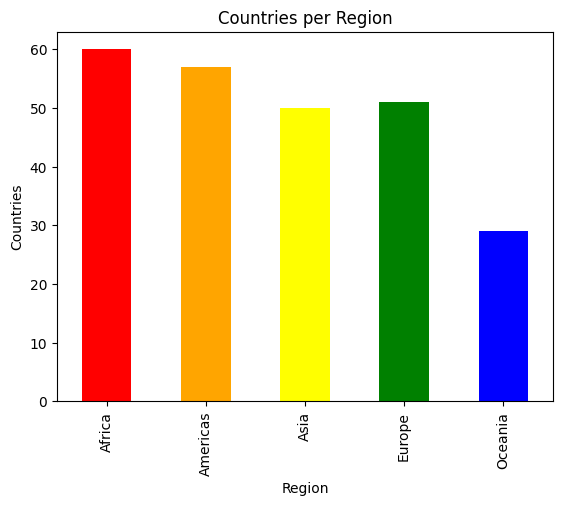

In [5]:
region_count_graph = region_count_table.plot(kind='bar', title='Countries per Region', color=graph_colours)
region_count_graph.set_xlabel('Region')
region_count_graph.set_ylabel('Countries')

Variables set in the above section:

| Variable Name | Elements | Type |
|--|--|--|
| countries_df | Country,Code,Region | Pandas DF |
| countries | Country Names | Array |
| regions | Region Names | Array |
| country_codes | Country Codes | Array |

## World Bank Development Indicator Data

I am attempting to explore how land usage affects climate change. The World Bank Development Indicators dataset includes use of land, electricity generation methods and volumes of CO2 produced by source.

In [6]:
# To fetch via a URL, use varible: utils.dev_indic_csv_url

# Load Data Set
devindic_df = pd.read_csv('../datasets/wbank_dev_indicators/38b7cb7a-172f-4be9-a48d-34d89fca9fc9_Data.csv')

# Drop columsn with No data
devindic_df.drop("2022 [YR2022]",axis=1,inplace=True)
devindic_df.drop("2023 [YR2023]",axis=1,inplace=True)

devindic_df.columns

Index(['Series Name', 'Series Code', 'Country Name', 'Country Code',
       '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]',
       '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]',
       '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]',
       '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]',
       '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]',
       '2020 [YR2020]', '2021 [YR2021]'],
      dtype='object')

In [7]:
# Rename Columns to more useful names
numerical_fields = [str(x).zfill(2) for x in range(2000,2022)]
string_fields = ["Series", "SeriesCode", "Country_WB", "ISOcode"]   # <-- Country_WB for WorldBank name
devindic_df.columns = (string_fields + numerical_fields)

devindic_df.columns


Index(['Series', 'SeriesCode', 'Country_WB', 'ISOcode', '2000', '2001', '2002',
       '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011',
       '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020',
       '2021'],
      dtype='object')

In [89]:
# Convert Column Data types for numerical data.
for column in numerical_fields:
   devindic_df[column] = devindic_df[column].astype(float)
   
for column in string_fields:
   devindic_df[column] = devindic_df[column].astype(str)
    
devindic_df.dtypes

Series         object
SeriesCode     object
Country_WB     object
ISOcode        object
2000          float64
2001          float64
2002          float64
2003          float64
2004          float64
2005          float64
2006          float64
2007          float64
2008          float64
2009          float64
2010          float64
2011          float64
2012          float64
2013          float64
2014          float64
2015          float64
2016          float64
2017          float64
2018          float64
2019          float64
2020          float64
2021          float64
dtype: object

## Separate Aggregated Data
As well as data for distinct countries, the World Bank dataset also includes data from aggregated regions. This data can be extracted from the working data set and saved for later use. The Kosovo country code is not found in the UNSD data. It is an empty row and can also be removed.

> Agricultural land (sq. km),AG.LND.AGRI.K2,Kosovo,XKX,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..

In [90]:
# Extract Regional Data
regional_data_only_df = pd.DataFrame(devindic_df[~devindic_df['ISOcode'].isin(country_codes)])
regional_data_only_df[["ISOcode","Country_WB"]].drop_duplicates()
regional_data_only_df.to_csv("../regional_data_only.csv")

# Country Data
country_data_df = pd.DataFrame(devindic_df[devindic_df['ISOcode'].isin(country_codes)])




The dataset contains a large number of elements where there is a null value; where there is no recorded data. This has been recorded in the dataset as a '..' value, and the datatype of the columns were consequently marked as 'object', rather than a float value during the CSV import. This indicates an unreported value for a given year.

In review of the data, there are also some zero values in the data (see next cell). These appear to be used interchanegably with the "..". For ther purposes of this study, unreported figures and zero figures are equivalent; they are likely to be classified as outliers.

In [91]:
# Showing a line in the dataset with multiple '..' values:
country_data_df.loc[country_data_df['Country_WB'] == "Sudan"].loc[country_data_df['SeriesCode'] == "AG.LND.EL5M.UR.K2"]

,Series,SeriesCode,Country_WB,ISOcode,2000,2001,2002,2003,2004,2005,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
983,Urban land area where elevation is below 5 met...,AG.LND.EL5M.UR.K2,Sudan,SDN,16.917873,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,22.714771,0.0,0.0,0.0,0.0,0.0,0.0


Replacing the ".." marker in all numerical data columns.

In [92]:
for column in numerical_fields:
    country_data_df[column] = country_data_df[column].replace("..","0")

In [93]:
# Showing the same line in the dataset:
country_data_df.loc[country_data_df['ISOcode'] == "GBR"].loc[country_data_df['SeriesCode'] == "AG.LND.EL5M.UR.K2"]



,Series,SeriesCode,Country_WB,ISOcode,2000,2001,2002,2003,2004,2005,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
1003,Urban land area where elevation is below 5 met...,AG.LND.EL5M.UR.K2,United Kingdom,GBR,787.223636,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,825.794982,0.0,0.0,0.0,0.0,0.0,0.0


This dataset is actually multiple tables of unrelated data concatenated, sharing the same column names. The Series Code is the key to each sub-table, each containing a complete set of records for each country. To confirm:

In [95]:
# Number of records per dataset, also number of countries
country_data_df.groupby(['SeriesCode'])['Country_WB'].count().head()

SeriesCode
AG.LND.AGRI.K2    215
AG.LND.AGRI.ZS    215
AG.LND.ARBL.HA    215
AG.LND.ARBL.ZS    215
AG.LND.CREL.HA    215
Name: Country_WB, dtype: int64

In [102]:
#To extract an individual sub table, the following example can be used:
    
df_AG_LND_AGRI_K2 = pd.DataFrame(country_data_df.loc[country_data_df['SeriesCode'] == "AG.LND.AGRI.K2"])
df_AG_LND_AGRI_K2.head()

,Series,SeriesCode,Country_WB,ISOcode,2000,2001,2002,2003,2004,2005,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Agricultural land (sq. km),AG.LND.AGRI.K2,Afghanistan,AFG,377940.0,377950.0,377900.0,378840.0,379280.0,379170.0,...,379140.0,379100.00,379100.0,379100.0,379100.0,379100.000,380100.000,380100.000,383130.000,383130.000
1,Agricultural land (sq. km),AG.LND.AGRI.K2,Albania,ALB,11440.0,11390.0,11400.0,11210.0,11220.0,10770.0,...,12013.0,11873.00,11742.9,11743.0,11817.0,11742.810,11740.810,11740.000,11655.550,11363.300
2,Agricultural land (sq. km),AG.LND.AGRI.K2,Algeria,DZA,400210.0,401090.0,398550.0,399057.0,411450.0,412110.0,...,413981.9,414316.35,414310.0,414564.0,413602.0,413351.408,413388.496,413160.710,413160.710,413160.710
3,Agricultural land (sq. km),AG.LND.AGRI.K2,American Samoa,ASM,22.7,23.0,23.3,23.6,23.9,24.2,...,26.3,26.60,26.9,27.2,27.5,27.800,28.100,28.400,28.700,29.000
4,Agricultural land (sq. km),AG.LND.AGRI.K2,Andorra,AND,230.0,227.5,228.5,228.6,228.1,218.0,...,187.6,188.10,188.0,188.1,188.2,188.200,188.340,188.001,187.773,187.562


There are 215 Country Names in this dataset and 217 in the UNSD dataset. This will need to be reconciled so that each country in the DevIndic dataset can be assigned a region for further analysis.


In [97]:
#new = pd.merge( devindic_df, countries_df, on=["ISOcode"], how='left')
new = pd.merge( df_AG_LND_AGRI_K2, countries_df, on=["ISOcode"], how='left')

new.head()
new.describe()

new.to_csv("../new.csv", sep=',', encoding='utf-8')

Let's fine out which country list is 'better':

In [98]:
print(new[['Country','Country_WB']])

                          Country             Country_WB
0                     Afghanistan            Afghanistan
1                         Albania                Albania
2                         Algeria                Algeria
3                  American Samoa         American Samoa
4                         Andorra                Andorra
..                            ...                    ...
210  United States Virgin Islands  Virgin Islands (U.S.)
211            State of Palestine     West Bank and Gaza
212                         Yemen            Yemen, Rep.
213                        Zambia                 Zambia
214                      Zimbabwe               Zimbabwe

[215 rows x 2 columns]


SORT THE COUNTRIES OUT.

In [99]:

new2 = (new.loc[new['Country'] != new['Country_WB']])[['ISOcode','Country','Country_WB']]
new2.to_csv("../countries-both-lists.csv", sep=',', encoding='utf-8')


Graph of Agricultural Area as a Test

In [172]:
# df_AG_LND_AGRI_K2

countries = ["France", "Germany"]

for c in countries:
    print (f"Working on {c}")
    c_data = df_AG_LND_AGRI_K2.loc[df_AG_LND_AGRI_K2['Country_WB'] == c]
    print (c_data.head())
    y = c_data.loc[:,numerical_fields]
    x = ['2000']
    
    c_data.plot(x=x, y=y)
    
    





#plt.show()

#graph = graph_data.plot(kind='line', title='Land Use', color=graph_colours)
#graph.set_xlabel('Year')
#graph.set_ylabel('Countries')
#graph.show

#seaborn.kdeplot(df_AG_LND_AGRI_K2[[numerical_fields]][df_AG_LND_AGRI_K2['Country'] == "Sudan"], label='Sudan')
#seaborn.kdeplot(graph_data['2000'][graph_data['Country'] == "Germany"], label='Germany')
#plt.xlabel('value')
#plt.ylabel('density')
#plt.show()

Working on France
                        Series      SeriesCode Country_WB ISOcode      2000  \
68  Agricultural land (sq. km)  AG.LND.AGRI.K2     France     FRA  298074.0   

        2001      2002      2003      2004      2005  ...      2012      2013  \
68  297133.0  296107.0  295346.0  294584.0  293904.0  ...  288448.0  287737.0   

        2014      2015       2016       2017      2018       2019       2020  \
68  287665.0  287269.0  287180.21  286974.99  286601.0  286211.86  285537.54   

         2021  
68  285537.54  

[1 rows x 26 columns]


ValueError: x must be a label or position

In [181]:
df_AG_LND_AGRI_K2.groupby("Country_WB").plot(x=[df_AG_LND_AGRI_K2[['2000']]], y=["2001"])


ValueError: Index data must be 1-dimensional

In [20]:
series_codes = wbd['Series Code'].unique()
series_names = wbd['Series Name'].unique()

NameError: name 'wbd' is not defined

In [ ]:
titles = zip(series_names,series_codes)
print (set(titles))

: 

In [ ]:
tbl_EN_ATM_CO2E_KT = wbd.loc[wbd['Series Code'] == "EN.ATM.CO2E.KT"]
tbl_AG_LND_TOTL_RU_K2 = wbd.loc[wbd['Series Code'] == "AG.LND.TOTL.RU.K2"]
tbl_EN_ATM_CO2E_KT

: 

: 

Variables set in the above section:

| Variable Name | Elements | Type |
|--|--|--|
| countries_df | Country,Code,Region | Pandas DF |
| countries | Country Names | Array |
| regions | Region Names | Array |
| country_codes | Country Codes | Array |

## Task 2 - Data Analysis


Task 2. Data analysis (LO2, LO3)
Formulate data analysis questions which could be answered by analysing your chosen dataset. For each question provide graph/chart along with your own interpretation. Please find the sample data analysis questions formulated for the ONS census dataset.

### Task Questions

- Describe the relationship between type of land use and CO2 emmissions, by country.
- Describe the change is land use by country, and by world region.
- Describe trends in land use.
- Predict how countries CO2 emmissions will trend.
- Does the region of the world collerate to Co2 emmissions?


: 